# 사전학습 ResNet18과 전이학습

목표: **ImageNet으로 사전학습된 ResNet18을 SVHN 숫자 분류에 재사용하는 전이학습의 핵심 흐름**을 이해하는 것이다.

### 핵심 질문

- 사전학습 모델과 무작위 초기화 모델은 무엇이 다른가
- ResNet18의 기존 1,000-class 출력층을 왜 교체하는가
- backbone을 freeze하면 어떤 파라미터가 학습되는가
- 새 classifier head는 어떻게 숫자 0~9를 학습하는가

### 전체 실습 흐름

```text
ImageNet weights가 있는 ResNet18 준비
→ ResNet 입력 규칙으로 SVHN 전처리
→ backbone freeze
→ Linear(512, 1000)을 Linear(512, 10)으로 교체
→ 선택 1: 공유받은 state_dict를 joblib로 불러오기
→ 선택 2: 새 classifier head 학습 후 joblib로 저장
→ test 정확도와 예측 이미지 확인
```

- ImageNet 입력 예시
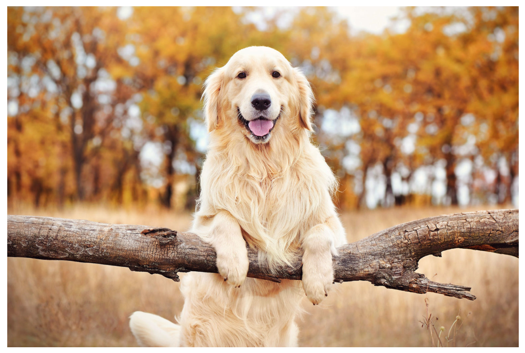

## 1. CNN 모델의 발전

ILSVRC는 ImageNet을 이용해 이미지 분류와 객체 탐지 성능을 비교한 대회이다. 2012년 AlexNet 이후 VGG, GoogLeNet과 ResNet이 등장하면서 CNN 기반 이미지 분류 성능이 크게 향상됐다.

> ImageNet: 스탠퍼드 대학교의 페이페이 리(Fei-Fei Li) 교수 연구팀이 구축한 1,400만 장 이상의 정제된 이미지 데이터베이스
> 이미지 속 물체가 무엇인지 컴퓨터가 학습할 수 있도록 정답(Label, 약 2만 개 이상의 카테고리)이 달려있다.

![ImageNet 대회의 CNN 성능 변화](https://d.pr/i/9p1so1+)

- 파란 막대는 **Top-5 오류율**이며 낮을수록 좋다.
- AlexNet 이후 모델이 깊어지고 학습 기법이 발전하면서 오류율이 감소했다.
- ResNet의 성능 향상은 깊이뿐 아니라 residual connection과 학습 방법의 발전이 함께 만든 결과이다.

![대표 CNN 모델의 정확도·연산량·파라미터 비교](https://d.pr/i/HwLSVx+)

- 왼쪽 막대는 Top-1 정확도이며 높을수록 좋다.
- 오른쪽 그래프는 연산량, 정확도와 파라미터 수를 함께 비교한다.
- VGG는 크고 연산량이 많으며, ResNet과 Inception 계열은 정확도와 효율의 균형을 개선했다.

> 않고 비교적 가벼운 **ResNet18**을 사용할 예정

## 2. 이미지 분류 성능지표

- **Top-1 Accuracy**: 모델의 첫 번째 예측이 정답인 이미지의 비율이다.
- **Top-5 Accuracy**: 상위 5개 예측 안에 정답이 포함된 이미지의 비율이다.
- **Top-5 Error**: 상위 5개 안에 정답이 없는 이미지의 비율이며 `1 - Top-5 Accuracy`로 계산한다.
- **Confidence**: 이미지 한 장에 대한 softmax 확률이며, 데이터셋 전체의 Accuracy와는 다른 개념이다.

```text
Top-5 Accuracy = 93.3%
Top-5 Error = 100% - 93.3% = 6.7%
```

ImageNet은 비슷한 품종과 사물 클래스가 많아 Top-1과 Top-5를 함께 사용한다. SVHN 숫자 분류의 최종 평가는 이해하기 쉬운 Top-1 Accuracy를 중심으로 진행한다.

## 3. ResNet18과 전이학습

> ResNet: 마이크로소프트 연구소에서 개발한 이미지 인식용 인공신경망(CNN) 모델
> '지름길(Shortcut Connection)' 구조를 도입하여 신경망의 층(Layer)을 너무 깊게 쌓으면 학습이 제대로 되지 않는 문제를 해결함 (ResNet152, 152층 까지도 학습 가능)
> 2015년 ImageNet 대회에서 압도적인 성적으로 우승

ResNet은 입력 정보를 몇 개 계층 뒤의 출력에 더하는 **residual connection**을 사용한다. 이 연결은 깊은 모델에서도 정보와 기울기가 전달되기 쉽게 만든다.

사전학습 ResNet18의 원래 입력과 출력은 다음과 같다.

```text
입력  : (N, 3, 224, 224) RGB 이미지
출력  : (N, 1000) ImageNet 클래스 logits
```

SVHN은 숫자 0~9의 10개 클래스이므로 기존 출력층을 교체한다.

```text
기존: backbone → 512개 특징 → Linear(512, 1000)
변경: backbone → 512개 특징 → Linear(512, 10)
```

처음에는 backbone의 가중치를 고정하고 새 출력층만 학습한다. 이것이 이번 노트북에서 확인할 **feature extraction 방식의 전이학습**이다.

## 4. 실행 설정

수업 전에 `ENABLE_DOWNLOAD=True`로 한 번 실행해 필요한 파일을 노트북 옆 `data` 폴더에 준비한다. 다운로드가 끝난 뒤에는 `False`로 되돌린다.

다음 파일이 포함된 `data` 폴더를 노트북과 함께 배포한다.

- `data/train_32x32.mat`: SVHN 훈련 데이터
- `data/test_32x32.mat`: SVHN 테스트 데이터
- `data/checkpoints/resnet18-f37072fd.pth`: ImageNet 사전학습 ResNet18 가중치
- `data/golden_retriever.jpg`: ImageNet 추론 예시 이미지

실행 모드는 다음처럼 구분한다.

- 파일을 최초 다운로드할 때: `ENABLE_DOWNLOAD=True`
- 배포받은 파일을 읽을 때: `ENABLE_DOWNLOAD=False`
- 새 모델을 학습·저장할 때: `ENABLE_TRAINING=True`
- 공유 모델을 불러올 때: `ENABLE_TRAINING=False`


In [1]:
from pathlib import Path

import joblib
import torch

SEED = 42
torch.manual_seed(SEED)

BATCH_SIZE = 64

# 학습/평가용 데이터 다운로드 여부
ENABLE_DOWNLOAD = False

ENABLE_TRAINING = False

# 저장된 데이터, 모델 경로
DATA_DIR = Path("data")
MODEL_DIR = Path("models")
MODEL_PATH = MODEL_DIR / "resnet18_svhn_state_dict.joblib"

# 모델 준비 여부
MODEL_READY = False

# 데이터 저장 폴더가 없으면 생성
DATA_DIR.mkdir(parents=True, exist_ok=True)

torch.hub.set_dir(str(DATA_DIR))

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("data directory:", DATA_DIR.resolve())
print("model path:", MODEL_PATH.resolve())
print("device:", device)
print("download enabled:", ENABLE_DOWNLOAD)
print("training enabled:", ENABLE_TRAINING)


data directory: C:\SKN_AI\07_deep_learning\02_cnn\data
model path: C:\SKN_AI\07_deep_learning\02_cnn\models\resnet18_svhn_state_dict.joblib
device: cpu
download enabled: False
training enabled: False


## 5. ImageNet weights와 입력 전처리

`ResNet18_Weights.DEFAULT`는 ImageNet에서 학습한 가중치, 1,000개 클래스 이름과 권장 입력 전처리를 제공한다.

`weights.transforms()`는 이미지에 다음 과정을 적용한다.

```text
Resize와 Center Crop
→ ToTensor
→ ImageNet RGB mean/std 정규화
→ (3, 224, 224) Tensor
```

사전학습 backbone을 그대로 재사용하므로 새로운 이미지도 모델이 학습할 때 사용한 입력 규칙에 맞춘다.

In [2]:
from torchvision import models
# ResNet18이 ImageNet 학습한(사전학습) 가중치를 반환받음
resnet_weights = models.ResNet18_Weights.DEFAULT
resnet_transform = resnet_weights.transforms()

# ResNet18이 가중치 데이터 파일이 있는지 확인
weights_path = (
    Path(torch.hub.get_dir())
    / "checkpoints"
    / Path(resnet_weights.url).name
)

if not weights_path.exists() and not ENABLE_DOWNLOAD:
    raise FileNotFoundError(
        f"ResNet18 weights가 없습니다: {weights_path}. "
    )

# ResNet18 모델 생성
# -> 직접 학습 X, 새롭게 모델 생성 후 학습된 가중치만 적용
imagenet_model = models.resnet18(weights=resnet_weights).to(device)
imagenet_model.eval()

print("weights:", resnet_weights)
print("weights cache:", weights_path)
print("original classifier:", imagenet_model.fc)
print("input transform:", resnet_transform)


weights: ResNet18_Weights.IMAGENET1K_V1
weights cache: data\checkpoints\resnet18-f37072fd.pth
original classifier: Linear(in_features=512, out_features=1000, bias=True)
input transform: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## 6. 사전학습 모델의 ImageNet 추론

출력층을 교체하기 전에 ResNet18이 ImageNet 분류기로 동작하는 모습을 확인한다.
이미지 한 장을 `(1, 3, 224, 224)` 미니배치로 만들고, 1,000개 logits 중 확률이 높은 5개 후보를 출력한다.

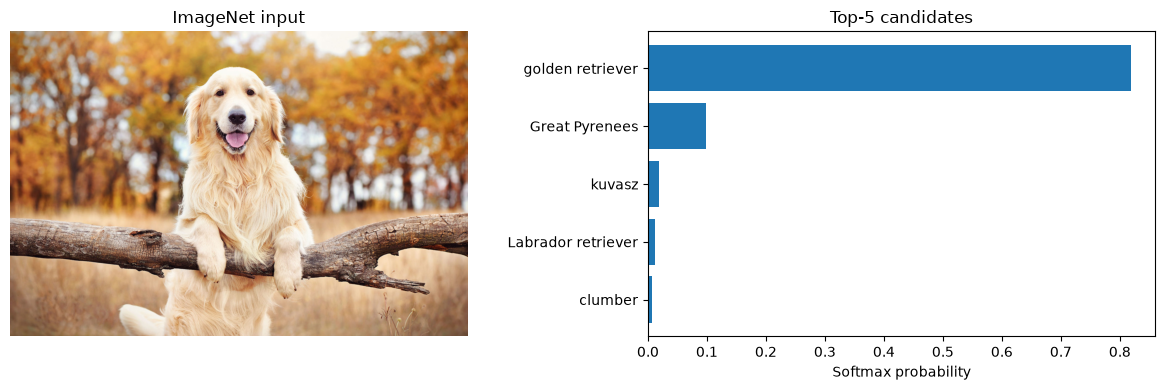

input shape: (1, 3, 224, 224)
logits shape: (1, 1000)
Top-5: [('golden retriever', 0.8190308213233948), ('Great Pyrenees', 0.09784317016601562), ('kuvasz', 0.01888432167470455), ('Labrador retriever', 0.011314681731164455), ('clumber', 0.0077097234316170216)]


In [3]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = DATA_DIR / "golden_retriever.jpg"

# PIL 이미지를 RGB로 통일하고 weights 전용 transform 적용
pil_image = Image.open(image_path).convert("RGB")
input_tensor = resnet_transform(pil_image) # (3, 224, 224)

# (3, 224, 224) - > (1, 3, 224, 224)
# torch가 CNN 수행할 수 있는 (N, C, H, W) 형식으로 변경
input_batch = input_tensor.unsqueeze(0).to(device)

with torch.no_grad():
    logits = imagenet_model(input_batch) # 예측(logit)
    probabilities = logits.softmax(dim=1) # 확률 구함

# topk(k=5): 확률이 가장 높은 클래스 5개의 확률과 인덱스 반환
top_probabilities, top_indices = probabilities.topk(k=5, dim=1)
class_names = resnet_weights.meta["categories"]
top5 = [
    (class_names[index], probability)
    for index, probability in zip(
        top_indices[0].cpu().tolist(),
        top_probabilities[0].cpu().tolist(),
    )
]

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(pil_image)
axes[0].set_title("ImageNet input")
axes[0].axis("off")

names = [name for name, _ in reversed(top5)]
values = [probability for _, probability in reversed(top5)]
axes[1].barh(names, values)
axes[1].set_xlabel("Softmax probability")
axes[1].set_title("Top-5 candidates")
plt.tight_layout()
plt.show()

print("input shape:", tuple(input_batch.shape))
print("logits shape:", tuple(logits.shape))
print("Top-5:", top5)


## 7. SVHN 데이터 준비

- Street View House Numbers(SVHN): 길에서 보이는 번호들

SVHN은 거리 사진에서 잘라낸 숫자 0~9 이미지 데이터셋이다. torchvision의 `SVHN`은 `root`로 지정한 폴더에서 `train_32x32.mat`과 `test_32x32.mat`을 직접 찾는다.

`ENABLE_DOWNLOAD=True`로 두 파일을 `data` 폴더에 한 번 내려받는다. 이후 전달받은 `data` 폴더를 노트북 옆에 두고 `ENABLE_DOWNLOAD=False`로 읽기만 하므로 수업 중 인터넷을 사용하지 않는다.

- train: 새 출력층의 가중치를 학습한다.
- validation: 학습 중 일반화 상태를 확인한다.
- test: 학습이 끝난 후 최종 정확도를 평가한다.


In [4]:
from torch.utils.data import DataLoader, random_split
from torchvision import datasets

required_svhn_files = [
    DATA_DIR / "train_32x32.mat",
    DATA_DIR / "test_32x32.mat",
]
missing_files = [path for path in required_svhn_files if not path.is_file()]

if missing_files and not ENABLE_DOWNLOAD:
    missing_text = "\n".join(f"- {path.resolve()}" for path in missing_files)
    raise FileNotFoundError(
        "SVHN 파일이 없습니다. 전달받은 data 폴더를 확인하세요.\n"
        f"{missing_text}"
    )

full_train_dataset = datasets.SVHN(
    root=DATA_DIR,
    split="train",
    download=ENABLE_DOWNLOAD,
    transform=resnet_transform,
)

test_dataset = datasets.SVHN(
    root=DATA_DIR,
    split="test",
    download=ENABLE_DOWNLOAD,
    transform=resnet_transform,
)

validation_size = int(len(full_train_dataset) * 0.15)
train_size = len(full_train_dataset) - validation_size
split_generator = torch.Generator().manual_seed(SEED)
train_dataset, validation_dataset = random_split(
    full_train_dataset,
    [train_size, validation_size],
    generator=split_generator,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("data directory:", DATA_DIR.resolve())
print("train file:", required_svhn_files[0].is_file())
print("test file:", required_svhn_files[1].is_file())
print("train:", len(train_dataset))
print("validation:", len(validation_dataset))
print("test:", len(test_dataset))


data directory: C:\SKN_AI\07_deep_learning\02_cnn\data
train file: True
test file: True
train: 62269
validation: 10988
test: 26032


## 8. SVHN 입력 이미지 확인

ResNet transform을 적용한 이미지는 `(3, 224, 224)`로 커지고 ImageNet mean/std로 정규화된다. 화면에 표시할 때만 역정규화하여 숫자가 잘리지 않았는지 확인한다.

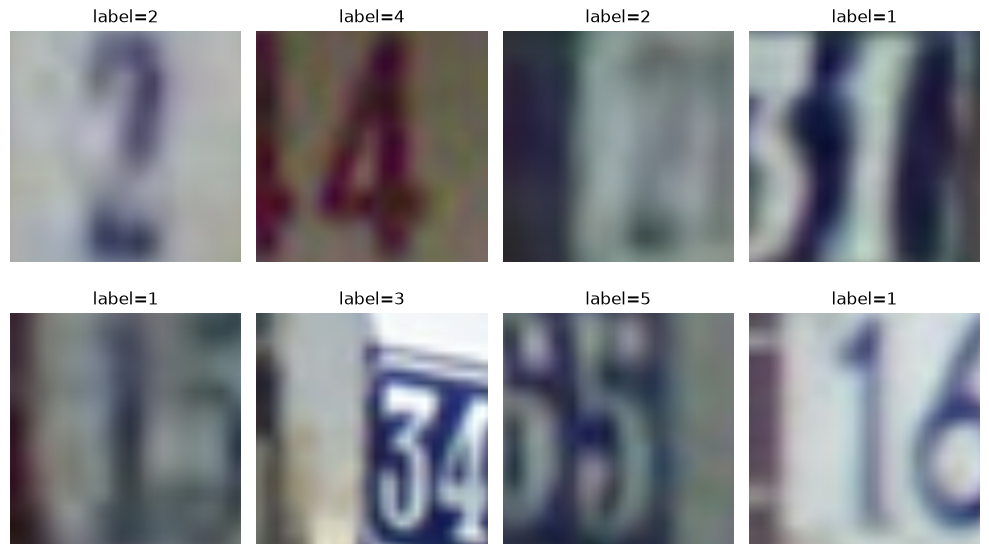

batch shape: (64, 3, 224, 224)
label shape: (64,)


In [7]:
sample_images, sample_labels = next(iter(train_loader))

# ImageNet 정규화를 시각화용으로 되돌리기 위해
# mean/std를 (3,1,1)로 만든다
imagenet_mean = torch.tensor(resnet_transform.mean).view(3, 1, 1)
imagenet_std = torch.tensor(resnet_transform.std).view(3, 1, 1)

figure, axes = plt.subplots(2, 4, figsize=(10, 6))
for index, axis in enumerate(axes.flat):
    display_image = (
        sample_images[index] * imagenet_std + imagenet_mean
    ).clamp(0, 1).permute(1, 2, 0)
    axis.imshow(display_image)
    axis.set_title(f"label={int(sample_labels[index])}")
    axis.axis("off")
plt.tight_layout()
plt.show()

print("batch shape:", tuple(sample_images.shape))
print("label shape:", tuple(sample_labels.shape))


## 9. Backbone freeze와 출력층 교체

전이학습의 핵심 단계이다.

- Backbone: 이미지에서 선, 모양, 무늬 같은 특징을 추출하는 ResNet18의 기존 합성곱 부분
- Freeze: 사전학습된 Backbone의 가중치가 학습 중 바뀌지 않도록 고정하는 것
- 출력층 교체: ImageNet의 1,000개 클래스를 예측하던 출력층을 SVHN 숫자 10개를 예측하는 층으로 바꾸는 것

1. ImageNet weights가 있는 ResNet18을 준비한다.
2. 모든 기존 파라미터를 `requires_grad=False`로 고정한다.
3. 기존 `Linear(512, 1000)`을 새로운 `Linear(512, 10)`으로 교체한다.
4. 새 출력층은 교체 후 생성됐으므로 기본값인 `requires_grad=True` 상태이다.

기존 모델: 이미지 → 사전학습 Backbone → 1,000개 클래스

변경 모델: 이미지 → 고정된 Backbone → 새 출력층 10개

In [9]:
import torch.nn as nn

# resnet18의 학습된 가중치를 이용해서 모델 생성
# (512, 1000, 224, 224)
transfer_model = models.resnet18(weights=resnet_weights)

# 사전학습된 resnet18을 은닉층에 두고 새로운 출력층을 추가
# -> 미리 만들어진 모델을 전달 받아 새 모델을 학습할 때 사용 == 전이학습

# 기존 resnet의 출력층이 받던 feature 수 확인
feature_count = transfer_model.fc.in_features
print("feature count:", feature_count)

# 원본(backbone)의 입려그 출력, 편향 확인
original_classifier = transfer_model.fc
print("original classifier:", original_classifier)

# backbone의 모든 가중치, 편향을 고정(freeze)
for parameter in transfer_model.parameters():
    parameter.requires_grad = False

# 출력층 교체 작업
# 기존: Linear(512, 1000)
# 교체: Linear(512, 10)
# 왜 10개? 숫자가 0~9까지 10개
transfer_model.fc = nn.Linear(feature_count, 10)
transfer_model = transfer_model.to(device)

trainable_parameter_count = sum(
    parameter.numel()
    for parameter in transfer_model.parameters()
    if parameter.requires_grad
)

print("기존 출력층:", original_classifier)
print("새 출력층:", transfer_model.fc)
print("학습 가능한 파라미터 수:", trainable_parameter_count)

feature count: 512
original classifier: Linear(in_features=512, out_features=1000, bias=True)
기존 출력층: Linear(in_features=512, out_features=1000, bias=True)
새 출력층: Linear(in_features=512, out_features=10, bias=True)
학습 가능한 파라미터 수: 5130


## 10. 공유받은 모델 가중치 불러오기

공유 받은 joblib 파일을 `models` 폴더에 둔 뒤 이 셀을 실행한다.
바로 앞에서 만든 `Linear(512, 10)` 구조의 `transfer_model`에 `load_state_dict()`로 학습된 가중치를 채운다.

`ENABLE_TRAINING=False`이면 긴 학습을 생략하고 공유 모델을 불러온 뒤 테스트로 이동한다. joblib 파일은 직접 전달받은 신뢰할 수 있는 파일만 불러온다.


In [10]:
if not ENABLE_TRAINING and MODEL_PATH.exists():
    state_dict = joblib.load(MODEL_PATH)

    # 바로 위에서 만든 Resnet18 구조에 학습된 파라미터를 채운다
    # -> 새로 만든 모델(ResNet에 출력층 변경한 모델)에
    #    SVHN이 학습된 모델의 파라미터(w,b)를 얻어와서 반영
    transfer_model.load_state_dict(state_dict)
    transfer_model.eval()
    MODEL_READY = True
    print("불러오기 완료:", MODEL_PATH)
elif ENABLE_TRAINING:
    MODEL_READY = False
    print("학습모드로 설정되어 있습니다")
else:
    MODEL_READY = False
    print(f"모델 파일이 없습니다: {MODEL_PATH.resolve()}")


불러오기 완료: models\resnet18_svhn_state_dict.joblib


## 11. 새 Classifier Head 학습

학습 과정은 앞에서 사용한 CNN과 같다. 차이점은 optimizer에 새 출력층의 파라미터만 전달한다는 것이다.

```text
zero_grad → forward → CrossEntropyLoss → backward → optimizer.step
```

backbone의 BatchNorm 통계가 바뀌지 않도록 전체 모델은 평가 모드로 유지하고 `fc`만 학습 모드로 둔다.

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(transfer_model.fc.parameters(), lr=1e-3)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

EPOCHS = 10

if ENABLE_TRAINING:
    for epoch in range(EPOCHS):
        # backbone의 BatchNorm은 고정하고 새 fc만 학습 대상으로 둔다.
        transfer_model.eval()
        transfer_model.fc.train()

        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = transfer_model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            current_batch_size = labels.size(0)
            train_loss_sum += loss.item() * current_batch_size
            train_correct += (logits.argmax(dim=1) == labels).sum().item()
            train_total += current_batch_size

        # validation에서는 가중치를 갱신하지 않는다.
        transfer_model.eval()
        validation_loss_sum = 0.0
        validation_correct = 0
        validation_total = 0

        with torch.no_grad():
            for images, labels in validation_loader:
                images = images.to(device)
                labels = labels.to(device)

                logits = transfer_model(images)
                loss = criterion(logits, labels)

                current_batch_size = labels.size(0)
                validation_loss_sum += loss.item() * current_batch_size
                validation_correct += (logits.argmax(dim=1) == labels).sum().item()
                validation_total += current_batch_size

        train_loss = train_loss_sum / train_total
        train_accuracy = train_correct / train_total
        validation_loss = validation_loss_sum / validation_total
        validation_accuracy = validation_correct / validation_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_accuracy)
        history["val_loss"].append(validation_loss)
        history["val_acc"].append(validation_accuracy)

        print(
            f"Epoch [{epoch + 1}/{EPOCHS}] "
            f"train_loss={train_loss:.4f} train_acc={train_accuracy:.4f} "
            f"val_loss={validation_loss:.4f} val_acc={validation_accuracy:.4f}"
        )

    # 모든 epoch가 끝났으므로 현재 모델은 테스트 가능한 상태이다.
    MODEL_READY = True
else:
    print("DRY-RUN: ENABLE_TRAINING=False로 설정되어 있어 학습을 진행하지 않습니다")

DRY-RUN: ENABLE_TRAINING=False로 설정되어 있어 학습을 진행하지 않습니다


## 12. 학습된 모델 가중치 내보내기

학습을 마친 뒤 이 셀을 실행하면 전체 모델의 `state_dict`를 CPU Tensor로 변환해 joblib 파일에 저장한다.
`state_dict`에는 학습된 weight와 bias뿐 아니라 BatchNorm의 통계값 같은 모델 상태도 포함된다.

모델 객체 전체를 저장하지 않고 `state_dict`를 저장하면 노트북에 정의된 클래스 이름을 찾지 못해 발생하는 `Can't get attribute ...` 오류를 피하기 쉽다.
모델 공유 시 생성된 `models/resnet18_svhn_state_dict.joblib` 파일만 공유하면 된다.

In [11]:
if ENABLE_TRAINING:
    MODEL_DIR.mkdir(parents=True, exist_ok=True)

    state_dict = {
        name: value.cpu()
        for name, value in transfer_model.state_dict().items()
    }
    joblib.dump(state_dict, MODEL_PATH)
    MODEL_READY = True
    print("저장 완료:", MODEL_PATH)
else:
    print("모델 저장 생략")


모델 저장 생략


## 13. 학습 곡선

손실과 정확도 그래프로 head가 학습되는지 확인한다. 간소화 버전에서는 조기 종료와 최적 상태 복원을 제외하고 핵심 학습 흐름에 집중한다.

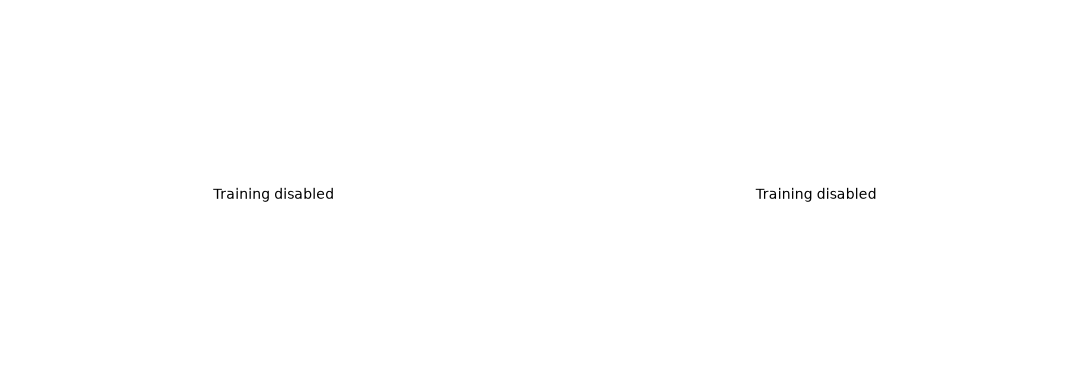

In [15]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4))

if history["train_loss"]:
    epoch_axis = range(1, len(history["train_loss"]) + 1)

    axes[0].plot(epoch_axis, history["train_loss"], marker="o", label="train")
    axes[0].plot(epoch_axis, history["val_loss"], marker="o", label="validation")
    axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross entropy")

    axes[1].plot(epoch_axis, history["train_acc"], marker="o", label="train")
    axes[1].plot(epoch_axis, history["val_acc"], marker="o", label="validation")
    axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Ratio")

    for axis in axes:
        axis.legend()
        axis.grid(alpha=0.3)
else:
    for axis in axes:
        axis.text(
            0.5,
            0.5,
            "Training disabled",
            ha="center",
            va="center",
            transform=axis.transAxes,
        )
        axis.axis("off")

plt.tight_layout()
plt.show()


## 14. Test 정확도와 예측 이미지

직접 학습했거나 joblib 파일에서 복원한 모델을 공식 test 데이터로 평가한다. 전체 Top-1 Accuracy와 예측 이미지 8개를 확인해 모델이 어떤 숫자를 혼동하는지 살펴본다.

test_loss=1.0336, Top-1 Accuracy=0.6709


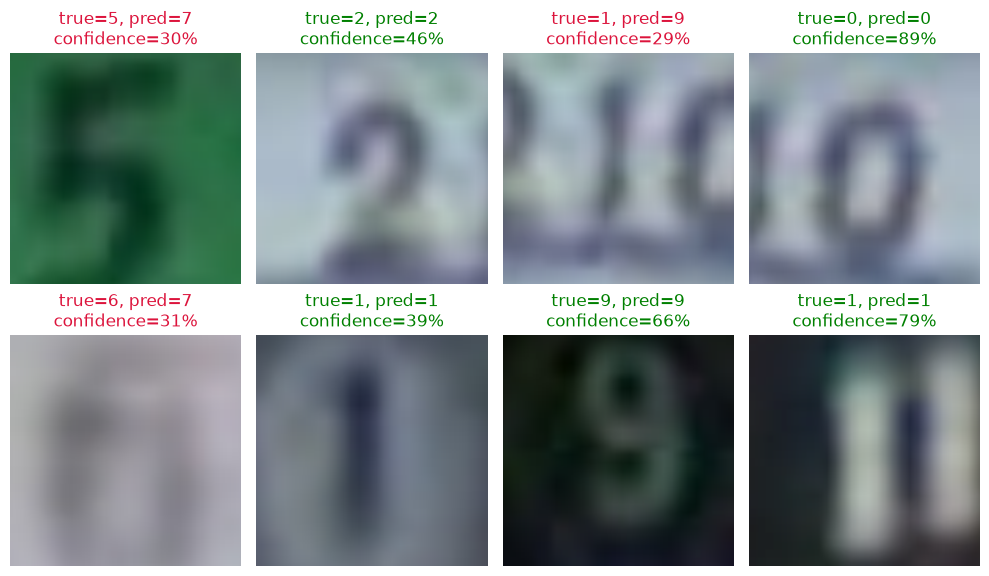

In [16]:
if MODEL_READY:
    transfer_model.eval()
    test_loss_sum = 0.0
    test_correct = 0
    test_total = 0
    prediction_examples = []

    with torch.no_grad():
        for images, labels in test_loader:
            input_images = images.to(device)
            target_labels = labels.to(device)

            logits = transfer_model(input_images)
            loss = criterion(logits, target_labels)
            probabilities = logits.softmax(dim=1)
            confidences, predictions = probabilities.max(dim=1)

            current_batch_size = labels.size(0)
            test_loss_sum += loss.item() * current_batch_size
            test_correct += (predictions == target_labels).sum().item()
            test_total += current_batch_size

            if len(prediction_examples) < 8:
                for image, actual, predicted, confidence in zip(
                    images,
                    labels,
                    predictions.cpu(),
                    confidences.cpu(),
                ):
                    prediction_examples.append(
                        (image, int(actual), int(predicted), float(confidence))
                    )
                    if len(prediction_examples) == 8:
                        break

    test_loss = test_loss_sum / test_total
    test_accuracy = test_correct / test_total
    print(f"test_loss={test_loss:.4f}, Top-1 Accuracy={test_accuracy:.4f}")

    figure, axes = plt.subplots(2, 4, figsize=(10, 6))
    for axis, (image, actual, predicted, confidence) in zip(
        axes.flat,
        prediction_examples,
    ):
        display_image = (
            image * imagenet_std + imagenet_mean
        ).clamp(0, 1).permute(1, 2, 0)
        axis.imshow(display_image)
        color = "green" if actual == predicted else "crimson"
        axis.set_title(
            f"true={actual}, pred={predicted}\nconfidence={confidence:.0%}",
            color=color,
        )
        axis.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("평가할 모델이 없다. 직접 학습하거나 공유받은 joblib 파일을 준비한다.")


# 테스트 진행 순서
# 약 26,000장 -> 배치 사이즈 64만큼 분할(410), (3,32,32)
# -> ResNet 기반 모델에 맞춰서 사이즈 변경(3, 224, 224)
#    (픽셀 수가 약 49배 증가)
# -> 모든 이미지가 ResNet18 (18계층) 통과 (합성곱 18회 수행)
# 결론: 오래 걸릴 수 밖에 없다

## 핵심 정리

1. ResNet18 구조만 불러오는 것과 ImageNet weights를 함께 불러오는 것은 다르다.
2. 사전학습 weights를 사용할 때는 해당 모델의 입력 transform을 함께 사용한다.
3. 기존 ResNet18은 512개 특징을 ImageNet logits 1,000개로 변환한다.
4. SVHN에서는 기존 출력층을 `Linear(512, 10)`으로 교체한다.
5. `requires_grad=False`로 backbone을 freeze하면 새 출력층만 학습된다.
6. 학습 순서는 기존 CNN과 동일한 `forward → loss → backward → step`이다.
7. 출력층 교체 직후 `load_state_dict()`로 공유 가중치를 복원해 학습을 생략할 수 있다.
8. 새 출력층을 학습한 직후 CPU `state_dict`를 joblib 파일로 저장해 공유한다.
9. validation으로 학습 상태를 확인하고 test는 마지막 최종 평가에 사용한다.
10. head만으로 부족할 때만 마지막 residual stage부터 fine-tuning한다.